In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None, engine='python', on_bad_lines='skip')
df = df[[0, 5]]
df.columns = ['polarity', 'text']
print(df.head())

   polarity                                               text
0         0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1         0  is upset that he can't update his Facebook by ...
2         0  @Kenichan I dived many times for the ball. Man...
3         0    my whole body feels itchy and like its on fire 
4         0  @nationwideclass no, it's not behaving at all....


In [ ]:
df = df[df.polarity != 2]

df['polarity'] = df['polarity'].map({0: 0, 4: 1})

print(df['polarity'].value_counts())

polarity
0    800000
1    800000
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    return text.lower()

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                          clean_text  
0  @switchfoot http://twitpic.com/2y1zl - awww, t...  
1  is upset that he can't update his facebook by ...  
2  @kenichan i dived many times for the ball. man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['polarity'],
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1280000
Test size: 320000


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (1280000, 5000)
TF-IDF shape (test): (320000, 5000)


In [ ]:
bnb = BernoulliNB()
bnb.fit(X_train_tfidf, y_train)

bnb_pred = bnb.predict(X_test_tfidf)

print("Bernoulli Naive Bayes Accuracy:", accuracy_score(y_test, bnb_pred))
print("\nBernoulliNB Classification Report:\n", classification_report(y_test, bnb_pred))

Bernoulli Naive Bayes Accuracy: 0.766478125

BernoulliNB Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76    159494
           1       0.76      0.78      0.77    160506

    accuracy                           0.77    320000
   macro avg       0.77      0.77      0.77    320000
weighted avg       0.77      0.77      0.77    320000



In [ ]:
sample_tweets = ["I love this!", "I hate that!", "It was okay, not great."]
sample_vec = vectorizer.transform(sample_tweets)

print("\nSample Predictions:")
print("BernoulliNB:", bnb.predict(sample_vec))



Sample Predictions:
BernoulliNB: [1 0 1]


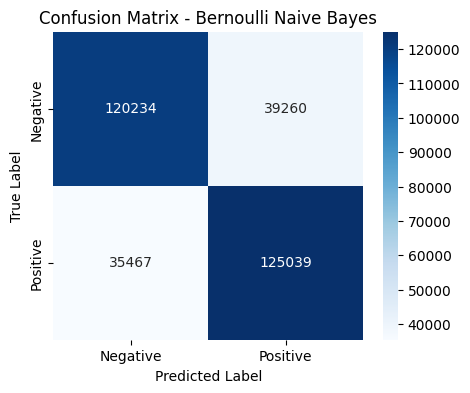

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, bnb_pred)
labels = ['Negative', 'Positive']

# Display using seaborn heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Bernoulli Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


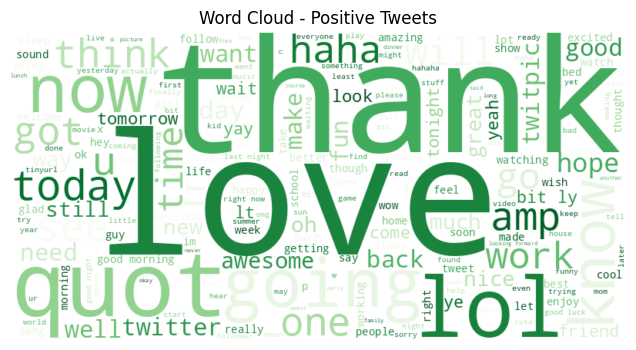

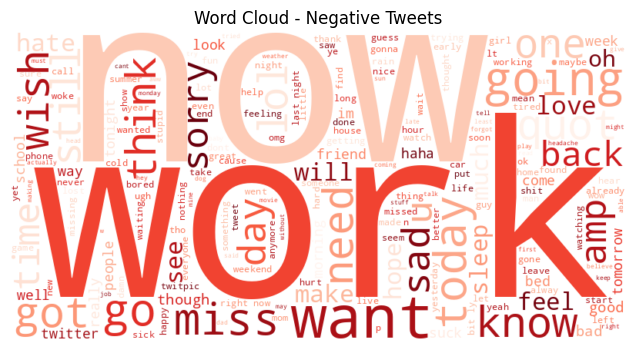

In [ ]:
from wordcloud import WordCloud

# Separate tweets by sentiment
positive_tweets = " ".join(df[df['polarity'] == 1]['clean_text'].values)
negative_tweets = " ".join(df[df['polarity'] == 0]['clean_text'].values)

# Word cloud for positive tweets
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_tweets)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Tweets')
plt.show()

# Word cloud for negative tweets
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_tweets)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Tweets')
plt.show()
